In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from scipy.stats import entropy, wasserstein_distance
from scipy.spatial.distance import jensenshannon

from src.config import load_config
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config
from src.unmixing import est_noise, hysime, mvsa, sunsal_mod

sns.set_style('whitegrid')
config = load_config()

In [2]:
def run_pipeline(Y_in, p, seed, verbose=False):
    np.random.seed(seed)
    w_hat, Rw_hat = est_noise(Y_in, noise_type='additive', verbose=False)
    kf, Ek, E, delta_p = hysime(Y_in, w_hat, Rw_hat, verbose=False)
    n_arch = p or kf
    endm, Sest, Up, my, sing_values = mvsa(
        Y_in, p=n_arch,
        MM_iters=config['unmixing'].getint('mvsa_mm_iters'),
        spherize='yes', verbose=0)
    abundances, res_p, res_d = sunsal_mod(
        endm, Y_in, positivity='yes', addone='yes',
        AL_iters=config['unmixing'].getint('sunsal_al_iters'),
        lambda_=0.0, tol=config['unmixing'].getfloat('sunsal_tol'), verbose='no')
    Y_rec = endm @ abundances
    rmse = float(np.sqrt(np.mean((Y_in - Y_rec) ** 2)))
    if verbose:
        print(f'kf={kf}, n_arch={n_arch}, RMSE={rmse:.6f}')
    return {'endm': endm, 'abundances': abundances, 'kf': int(kf),
            'n_arch': int(n_arch), 'rmse': rmse}

In [3]:
SEED = config['unmixing'].getint('seed')
np.random.seed(SEED)

# Number of archetypes
P = config['unmixing'].getint('n_archetypes') or None

df = load_complete(config)

n_trials = 10
results = []

for trial in tqdm.tqdm(range(n_trials)):
    # print(f'Trial {trial + 1}/{n_trials}')
    np.random.seed(SEED + trial)

    pre = preprocess_from_config(df, config)
    Y_raw = pre.Y_raw
    Y = pre.Y
    L, N = Y.shape
    labels = pre.candidate_labels

    results_t = run_pipeline(Y, p=P, seed=SEED + trial, verbose=False)
    results.append(results_t)

  0%|          | 0/10 [00:00<?, ?it/s]

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
 10%|█         | 1/10 [00:02<00:19,  2.17s/it]

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
 20%|██        | 2/10 [00:05<00:24,  3.08s/it]

...

/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
 80%|████████  | 8/10 [00:19<00:04,  2.38s/it]

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
 90%|█████████ | 9/10 [00:23<00:02,  2.63s/it]

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
100%|██████████| 10/10 [00:25<00:00,  2.51s/it]


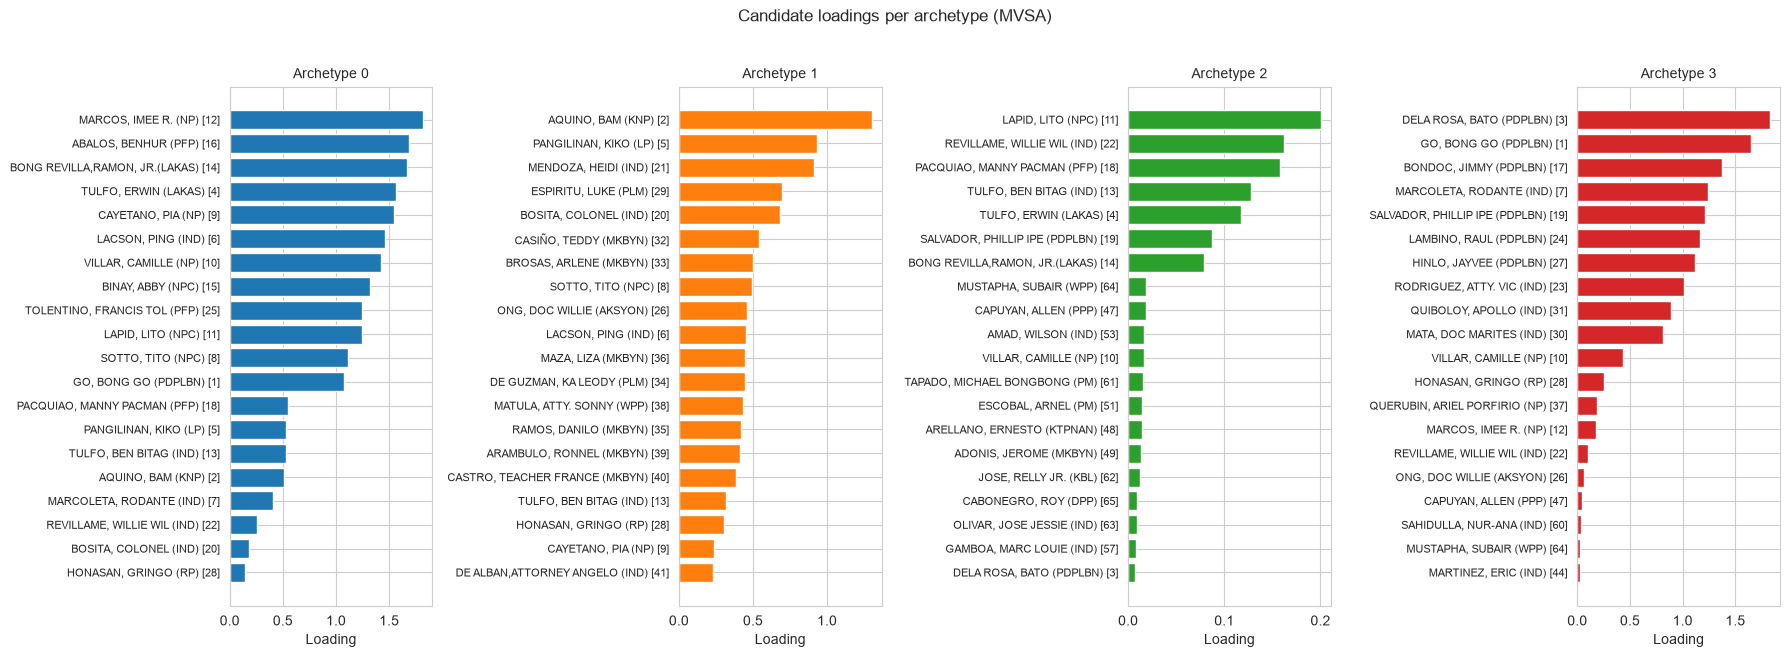

In [4]:
from src.figures import plot_archetypes_loadings_grid

candidate_labels = pre.candidate_labels

plot_archetypes_loadings_grid(results[2]["endm"], candidate_labels, top_n=20,
                              suptitle='Candidate loadings per archetype (MVSA)')

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

<Axes: >

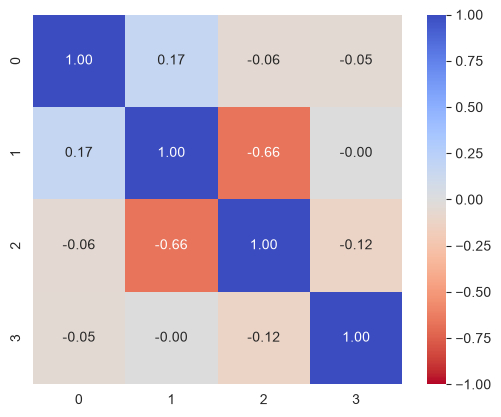

In [6]:
sns.heatmap(cosine_similarity(results[2]["endm"].T), annot=True, fmt=".2f", cmap='coolwarm_r', square=True, vmin=-1, vmax=1)

In [7]:
results[2]["endm"].shape

(66, 4)

In [8]:
endmember_ranked_candidates = np.array([
    np.array(pre.candidate_labels)[np.argsort(-results[0]["endm"][:, i])]
    for i in range(results[0]["endm"].shape[1])
])

In [9]:
endmember_ranked_candidates.shape

(4, 66)

<Axes: >

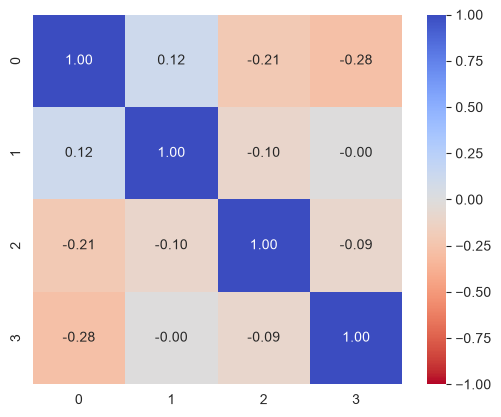

In [10]:
from scipy.stats import spearmanr

sns.heatmap(spearmanr(endmember_ranked_candidates[:12].T)[0], annot=True, fmt=".2f", cmap='coolwarm_r', square=True, vmin=-1, vmax=1)


## Archetype distinctness — metric prototypes

Each archetype is a column of `endm` (shape `L candidates × p archetypes`): a loading
profile over candidates. To gauge how "far apart" archetypes are — and ultimately pick the
largest `p` whose archetypes stay mutually distinct — we try three families of metrics:

- **Loading-weighted geometry** (uses magnitudes): full cosine, cosine on the top-`k` union,
  Hellinger & Jensen–Shannon distance (columns normalised to distributions), Ružička
  (weighted Jaccard). These put most weight on the large loadings automatically.
- **Rank-based, top-weighted** (uses the ordering, extra weight on the top): weighted
  Kendall τ and rank-biased overlap (RBO). Both emphasise agreement among the top-ranked
  candidates; plain Spearman/Kendall weight every rank equally.
- **Rank-based, set overlap** (top-`k` only, ignores exact order within the set): top-`k`
  Jaccard — the simplest "do the headline candidates coincide?" check.

**Convention:** each metric returns its *native* `p×p` matrix (a similarity or a distance);
`to_distance` maps all of them onto a common **0 = identical … 1 = maximally distinct** scale
so they can be compared and aggregated when choosing `p`.

> **On Elo:** Elo rates *players* from pairwise match outcomes, so it answers "which archetype
> is stronger / ranks higher", not "how much do two archetypes overlap". For the overlap
> question the top-weighted rank metrics (weighted τ, RBO) capture the same intuition more
> directly. A faithful Elo adaptation is included further down for comparison, but it measures
> a different thing.

In [11]:
from itertools import combinations
from scipy.stats import weightedtau, spearmanr
from scipy.spatial.distance import jensenshannon


def ranked_idx(col):
    """Candidate indices sorted by *descending* loading.

    (np.argsort has no `descending=` kwarg — negate the array instead.)
    """
    return np.argsort(-np.asarray(col))


def _as_distribution(col):
    """Clip negatives and normalise a loading column to a probability vector."""
    x = np.clip(np.asarray(col, float), 0, None)
    s = x.sum()
    return x / s if s > 0 else np.full_like(x, 1.0 / len(x))


def _pairwise(E, f, diag):
    """Symmetric p×p matrix from a per-pair function f(col_a, col_b)."""
    p = E.shape[1]
    M = np.full((p, p), float(diag))
    for a, b in combinations(range(p), 2):
        M[a, b] = M[b, a] = f(E[:, a], E[:, b])
    return M


# --- loading-weighted geometry -------------------------------------------------
def m_cosine_full(E):
    return cosine_similarity(E.T)


def m_cosine_top(E, k=12):
    def f(u, v):
        idx = np.union1d(ranked_idx(u)[:k], ranked_idx(v)[:k])
        a, b = u[idx], v[idx]
        return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))
    return _pairwise(E, f, diag=1.0)


def m_hellinger(E):
    def f(u, v):
        u, v = _as_distribution(u), _as_distribution(v)
        return float(np.sqrt(0.5 * np.sum((np.sqrt(u) - np.sqrt(v)) ** 2)))
    return _pairwise(E, f, diag=0.0)


def m_jensen_shannon(E):
    f = lambda u, v: float(jensenshannon(_as_distribution(u), _as_distribution(v), base=2))
    return _pairwise(E, f, diag=0.0)


def m_ruzicka(E):
    def f(u, v):                                     # weighted Jaccard on loadings
        u, v = np.clip(u, 0, None), np.clip(v, 0, None)
        return float(np.minimum(u, v).sum() / (np.maximum(u, v).sum() + 1e-12))
    return _pairwise(E, f, diag=1.0)


# --- rank-based ----------------------------------------------------------------
def m_spearman(E):
    return _pairwise(E, lambda u, v: float(spearmanr(u, v).correlation), diag=1.0)


def m_weighted_tau(E):                               # top ranks weighted most (hyperbolic)
    return _pairwise(E, lambda u, v: float(weightedtau(u, v, rank=True)[0]), diag=1.0)


def rbo_ext(list_a, list_b, pval=0.9, k=None):
    """Extrapolated rank-biased overlap (Webber et al. 2010).

    Top-weighted agreement between two ranked index lists; `pval` sets how fast
    weight decays with depth (smaller = more top-heavy). Identical lists → 1.0.
    """
    if k:
        list_a, list_b = list_a[:k], list_b[:k]
    depth = min(len(list_a), len(list_b))
    sa, sb, rbo_sum, overlap = set(), set(), 0.0, 0
    for d in range(depth):
        sa.add(list_a[d]); sb.add(list_b[d])
        overlap = len(sa & sb)
        rbo_sum += (pval ** d) * (overlap / (d + 1))
    ext = (overlap / depth) * (pval ** depth)        # assume top-depth agreement persists
    return (1 - pval) * rbo_sum + ext


def m_rbo(E, pval=0.9, k=None):
    lists = [ranked_idx(E[:, i]).tolist() for i in range(E.shape[1])]
    p = E.shape[1]
    M = np.ones((p, p))
    for a, b in combinations(range(p), 2):
        M[a, b] = M[b, a] = rbo_ext(lists[a], lists[b], pval, k)
    return M


def m_topk_jaccard(E, k=12):
    def f(u, v):
        A, B = set(ranked_idx(u)[:k]), set(ranked_idx(v)[:k])
        return len(A & B) / len(A | B)
    return _pairwise(E, f, diag=1.0)


# --- registry + common 0..1 distance scale -------------------------------------
METRICS = {
    'cosine_full':    dict(fn=m_cosine_full,    kind='sim', signed=True),
    'cosine_top20':   dict(fn=m_cosine_top,     kind='sim', signed=True),
    'hellinger':      dict(fn=m_hellinger,      kind='dist'),
    'jensen_shannon': dict(fn=m_jensen_shannon, kind='dist'),
    'ruzicka':        dict(fn=m_ruzicka,        kind='sim', signed=False),
    'spearman':       dict(fn=m_spearman,       kind='sim', signed=True),
    'weighted_tau':   dict(fn=m_weighted_tau,   kind='sim', signed=True),
    'rbo':            dict(fn=m_rbo,            kind='sim', signed=False),
    'topk_jaccard12': dict(fn=m_topk_jaccard,   kind='sim', signed=False),
}


def to_distance(M, meta):
    """Map any metric matrix onto 0 = identical … 1 = maximally distinct."""
    if meta['kind'] == 'dist':
        return M                       # Hellinger / JS already 0..1, 0 = identical
    if meta.get('signed'):
        return (1 - M) / 2             # [-1, 1] similarity -> [0, 1] distance
    return 1 - M                       # [0, 1] similarity  -> distance

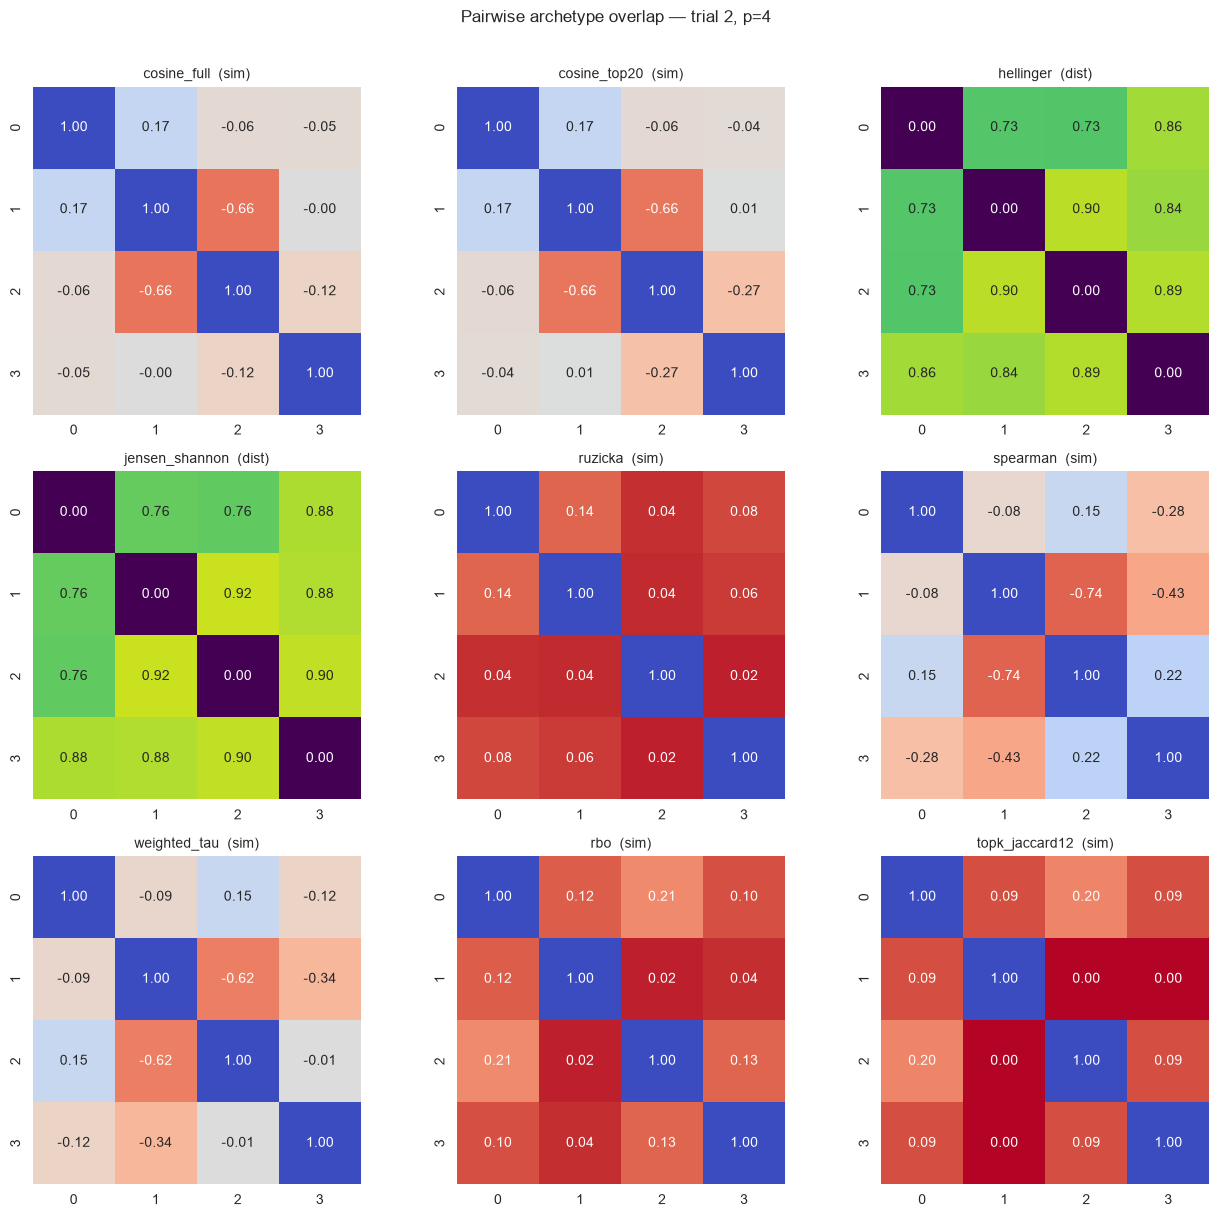

In [12]:
# Compute every metric on one trial's endmembers and show them side by side.
trial = 2
E = results[trial]["endm"]          # (L candidates, p archetypes)
labels = pre.candidate_labels

mats = {name: meta['fn'](E) for name, meta in METRICS.items()}

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for ax, (name, M) in zip(axes.flat, mats.items()):
    meta = METRICS[name]
    if meta['kind'] == 'dist':
        cmap, vmin, vmax = 'viridis', 0, 1
    elif meta.get('signed'):
        cmap, vmin, vmax = 'coolwarm_r', -1, 1
    else:
        cmap, vmin, vmax = 'coolwarm_r', 0, 1
    sns.heatmap(M, annot=True, fmt='.2f', cmap=cmap, square=True,
                vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.set_title(f"{name}  ({meta['kind']})", fontsize=10)
for ax in axes.flat[len(mats):]:
    ax.set_visible(False)
fig.suptitle(f'Pairwise archetype overlap — trial {trial}, p={E.shape[1]}', y=1.01)
fig.tight_layout()
plt.show()

### A multi-way "Venn" of archetypes

Points are candidates; one translucent polygon (the convex hull of its top-`k`) per archetype —
overlapping hulls = shared candidates. Layout is **radviz**: the `p` archetypes are anchors
equally spaced on a circle (stars), and each candidate is pulled toward every anchor in
proportion to its loadings. So a candidate loaded entirely on one archetype sits on that star, one
shared between two sits on the line between them, and a jack-of-all-archetypes lands near the
centre. Point colour = the candidate's top archetype; size ∝ its peak loading.

This is a *qualitative* companion to the distance heatmaps: both the 2-D squeeze and the convex
hull (which can swallow non-member candidates in its interior) distort the true overlap, so read
it for intuition and trust the metrics for the numbers. Pass `embed='pca'` to let the geometry
fall out of a plain PCA of the loadings instead of the radviz anchors.

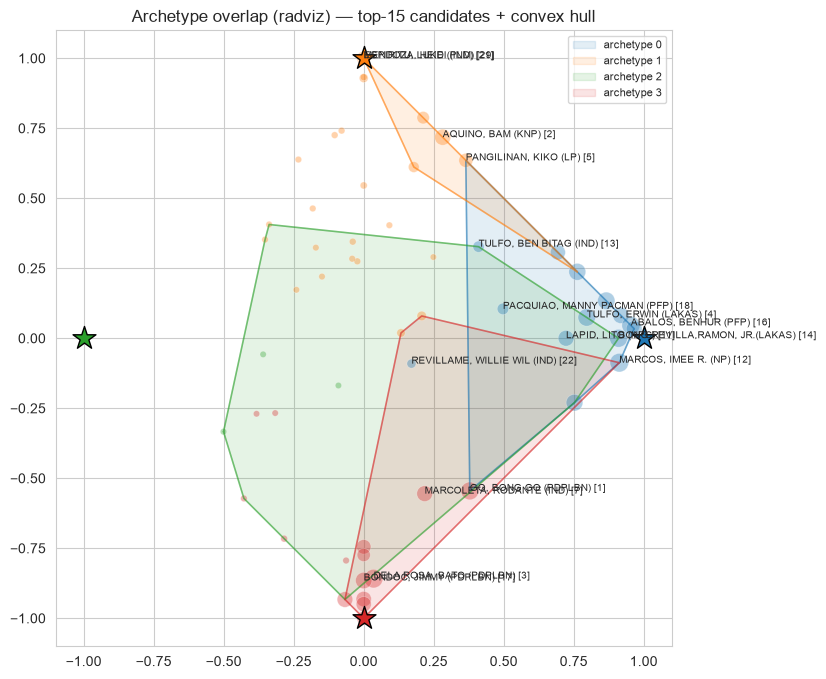

In [13]:
from scipy.spatial import ConvexHull
from sklearn.decomposition import PCA


def _venn_coords(E, embed):
    """2-D candidate coordinates. 'radviz': archetype anchors on a circle, each
    candidate placed at the loading-weighted average of the anchors. 'pca': plain
    PCA of the loading rows."""
    W = np.clip(E, 0, None)
    p = E.shape[1]
    if embed == 'radviz':
        ang = 2 * np.pi * np.arange(p) / p
        anchors = np.column_stack([np.cos(ang), np.sin(ang)])
        s = W.sum(1, keepdims=True)
        Wn = np.divide(W, s, out=np.full_like(W, 1.0 / p), where=s > 0)
        return Wn @ anchors, anchors
    return PCA(n_components=2).fit_transform(E), None


def archetype_venn(E, labels, top_k=15, annotate=4, embed='radviz', ax=None):
    """Candidates as points, each archetype's top-k as a translucent convex hull.

    Overlapping hulls = shared top candidates. Point colour = candidate's top
    archetype, size ~ its peak loading; stars mark the radviz anchors.
    """
    L, p = E.shape
    coords, anchors = _venn_coords(E, embed)
    members = [np.argsort(-E[:, a])[:top_k] for a in range(p)]
    owner = E.argmax(1)
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 8))
    colors = plt.cm.tab10(np.arange(p) % 10)

    ax.scatter(coords[:, 0], coords[:, 1], s=20 + 160 * (E.max(1) / E.max()),
               c=[colors[o] for o in owner], alpha=0.35,
               edgecolor='white', linewidth=0.5, zorder=2)

    for a in range(p):
        pts = coords[members[a]]
        if len(np.unique(pts, axis=0)) >= 3:
            poly = pts[ConvexHull(pts).vertices]
            ax.fill(poly[:, 0], poly[:, 1], color=colors[a], alpha=0.12, zorder=1,
                    label=f'archetype {a}')
            ax.plot(np.r_[poly[:, 0], poly[0, 0]], np.r_[poly[:, 1], poly[0, 1]],
                    color=colors[a], lw=1.2, alpha=0.6, zorder=3)
        if anchors is not None:
            ax.scatter(*anchors[a], marker='*', s=300, color=colors[a],
                       edgecolor='k', zorder=5)

    seen = set()
    for a in range(p):
        for c in members[a][:annotate]:
            if c not in seen:
                ax.annotate(labels[c], coords[c], fontsize=7, zorder=6)
                seen.add(c)

    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title(f'Archetype overlap ({embed}) — top-{top_k} candidates + convex hull')
    return ax


archetype_venn(E, labels, top_k=15, embed='radviz')
plt.show()

### Spider / radar view

The same overlap unrolled onto a circle: each **spoke is a candidate** and each archetype is a
closed translucent polygon whose radius at a spoke is that candidate's loading. Candidates are
ordered by their dominant archetype, so each archetype forms a **lobe** in its own sector; where a
polygon bulges into a neighbour's sector it shares those candidates — that bulge *is* the overlap.
Spoke labels are coloured by owning archetype.

Radii are column-normalised by default (each archetype reaches 1 at its own top candidate) so the
*shapes* are comparable regardless of loading scale. Use `normalize='row'` to instead show, per
candidate, how its support splits across archetypes, or `normalize=None` for raw loadings. `top_k`
sets how many spokes (the union of each archetype's top-k).

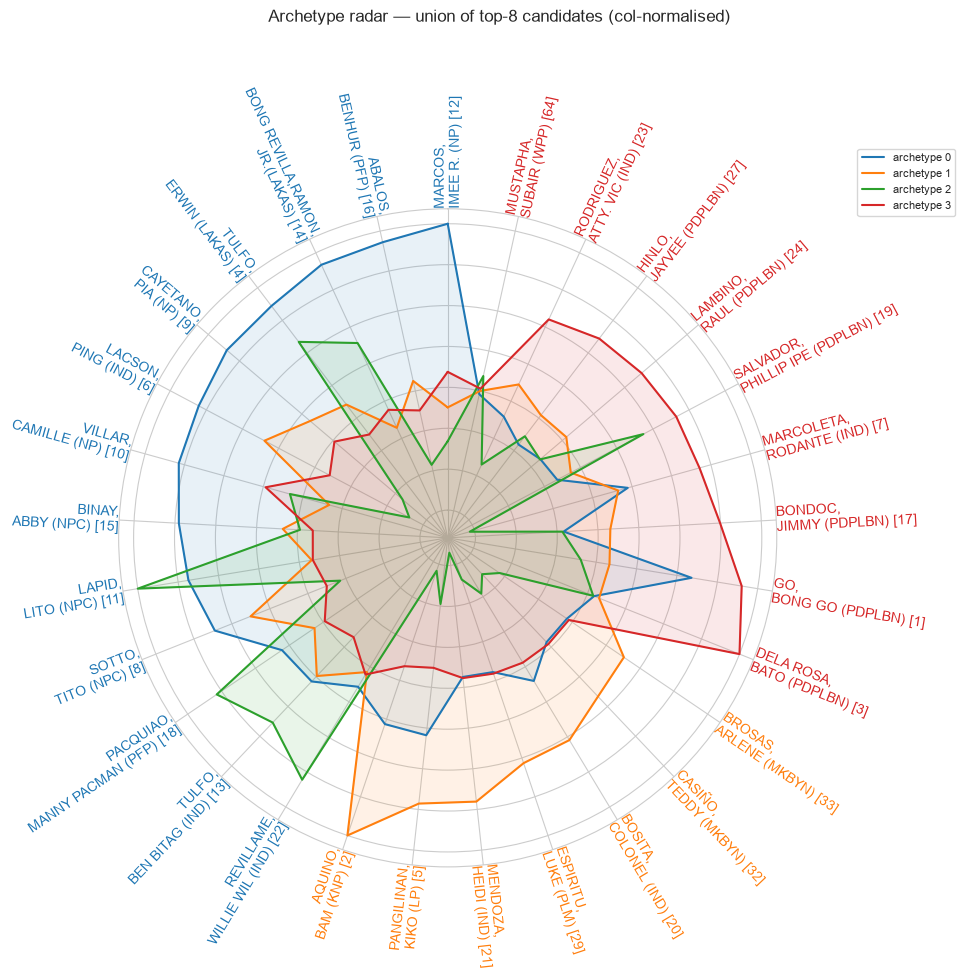

In [14]:
def archetype_radar(E, labels, top_k=8, normalize='col', ax=None, figsize=(10, 10)):
    """Spider/radar chart: each spoke a candidate, each archetype a closed polygon.

    Candidates are the union of every archetype's top-k, ordered by their dominant
    archetype so each archetype forms a lobe in its own sector; a polygon bulging
    into a neighbour's sector = shared candidates. normalize: 'col' (each archetype
    reaches 1 at its own peak), 'row' (per-candidate split across archetypes), or
    None (raw loadings). Spoke labels sit at the rim, aligned along their ray,
    broken after the "Last, First" comma, and coloured by owning archetype.
    """
    L, p = E.shape
    sel = np.array(sorted(set().union(*[set(np.argsort(-E[:, a])[:top_k])
                                        for a in range(p)])))
    Es = E[sel]
    owner = Es.argmax(1)
    order = np.lexsort((-Es.max(1), owner))        # group by owner, then strongest first
    sel, Es, owner = sel[order], Es[order], owner[order]
    m = len(sel)
    if normalize == 'col':
        Z = Es / (Es.max(0) + 1e-12)
    elif normalize == 'row':
        Z = Es / (Es.sum(1, keepdims=True) + 1e-12)
    else:
        Z = Es
    ang = np.linspace(0, 2 * np.pi, m, endpoint=False)
    ca = np.r_[ang, ang[0]]
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
    colors = plt.cm.tab10(np.arange(p) % 10)
    for a in range(p):
        r = np.r_[Z[:, a], Z[0, a]]
        ax.plot(ca, r, color=colors[a], lw=1.5, label=f'archetype {a}')
        ax.fill(ca, r, color=colors[a], alpha=0.1)

    ax.set_theta_offset(np.pi / 2)
    ax.set_yticklabels([])
    ax.set_xticks(ang)
    ax.set_xticklabels([])                            # draw our own labels, radially aligned
    # NB: don't force ylim to 0 — real endmembers have negative loadings and
    # clamping them to the centre distorts the polygons. Use the autoscaled rim.

    tdir, toff = ax.get_theta_direction(), ax.get_theta_offset()
    rmax = ax.get_ylim()[1]
    for angle, o, c in zip(ang, owner, sel):
        deg = np.degrees(tdir * angle + toff) % 360   # on-screen angle of this ray
        flip = 90 < deg < 270                         # keep left-half text upright
        ax.text(angle, rmax, labels[c].replace(', ', ',\n', 1),
                color=colors[o], fontsize=10,
                rotation=deg + 180 if flip else deg, rotation_mode='anchor',
                ha='right' if flip else 'left', va='center')

    ax.legend(loc='upper right', bbox_to_anchor=(1.28, 1.1), fontsize=8)

    plt.tight_layout()
    plt.suptitle(f'Archetype radar — union of top-{top_k} candidates '
                 f'({normalize}-normalised)', y=1.02)
    return ax


archetype_radar(E, labels, top_k=8, normalize='col')
plt.show()

### Elo — candidates as players

Here candidates are the *players* and each archetype is its own *tournament*: draw two
candidates, the one the archetype loads higher wins, update Elo. Each archetype thus becomes a
candidate **rating vector** `R[:, a]` — a leaderboard you can read directly.

To get back to *overlap between archetypes*, compare those rating vectors. Prototyping exposed
two cautions worth keeping in mind:

- **Uniform pairings make Elo recover the loading order** (spearman ≈ 1.0). So comparing
  archetypes by their raw rating vectors is ≈ a rank correlation — it mostly duplicates
  `spearman` / `weighted_tau` above rather than adding information. (Weighting *who plays* by
  loading instead starves the near-zero tail of matches, pins it at the 1500 base, and makes
  every rating vector nearly identical — degenerate, so avoid it.)
- Where Elo earns its keep is the **consensus-deviation fingerprint**: pool all archetypes into
  one baseline rating, then look at each archetype's `R[:, a] − baseline`. That strips out the
  shared "strong everywhere" component and leaves each archetype's distinctive
  over/under-performers — a sharper distinctness signal. The two heatmaps below contrast raw
  vs fingerprint.

The `margin` knob (logistic of the loading gap) is how you put extra weight on the big
loadings; set `margin=False` for plain win/lose.

archetype 0: MARCOS, IMEE R. (NP) [12] (1958), ABALOS, BENHUR (PFP) [16] (1921), BONG REVILLA,RAMON, JR.(LAKAS) [14] (1915), TULFO, ERWIN (LAKAS) [4] (1884), CAYETANO, PIA (NP) [9] (1879), LACSON, PING (IND) [6] (1853), VILLAR, CAMILLE (NP) [10] (1844), BINAY, ABBY (NPC) [15] (1812)
archetype 1: AQUINO, BAM (KNP) [2] (2163), PANGILINAN, KIKO (LP) [5] (1962), MENDOZA, HEIDI (IND) [21] (1954), ESPIRITU, LUKE (PLM) [29] (1820), BOSITA, COLONEL (IND) [20] (1811), CASIÑO, TEDDY (MKBYN) [32] (1725), BROSAS, ARLENE (MKBYN) [33] (1696), SOTTO, TITO (NPC) [8] (1693)
archetype 2: LAPID, LITO (NPC) [11] (2012), REVILLAME, WILLIE WIL (IND) [22] (1924), PACQUIAO, MANNY PACMAN (PFP) [18] (1915), TULFO, BEN BITAG (IND) [13] (1846), TULFO, ERWIN (LAKAS) [4] (1823), SALVADOR, PHILLIP IPE (PDPLBN) [19] (1754), BONG REVILLA,RAMON, JR.(LAKAS) [14] (1734), MUSTAPHA, SUBAIR (WPP) [64] (1597)
archetype 3: DELA ROSA, BATO (PDPLBN) [3] (2097), GO, BONG GO (PDPLBN) [1] (2037), BONDOC, JIMMY (PDPLBN) [17] (1937)

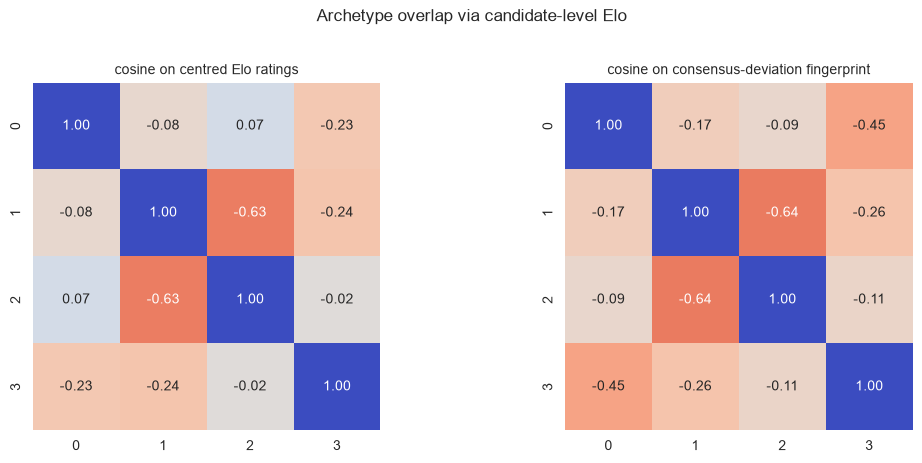

In [15]:
# --- Elo with CANDIDATES as players -------------------------------------------
def elo_candidate_ratings(col, n_matches=30000, K=16, base=1500, margin=True, seed=0):
    """Elo rating of each candidate from one archetype's loadings.

    Candidates are players; a match draws two at random and the higher-loading one
    wins. Pairs are sampled *uniformly* so every candidate plays (Elo then recovers
    the loading order). With margin=True the result is a logistic of the loading
    gap, so decisive gaps — which involve the big loadings — move ratings more.
    """
    rng = np.random.default_rng(seed)
    L = len(col)
    R = np.full(L, float(base))
    scale = np.std(col) + 1e-9
    for _ in range(n_matches):
        i, j = rng.choice(L, size=2, replace=False)
        if margin:
            s = 1.0 / (1.0 + np.exp(-(col[i] - col[j]) / scale))
        else:
            s = 0.5 if col[i] == col[j] else float(col[i] > col[j])
        ei = 1 / (1 + 10 ** ((R[j] - R[i]) / 400))
        d = K * (s - ei)
        R[i] += d; R[j] -= d
    return R


def elo_rating_matrix(E, **kw):
    """(L, p) matrix: Elo rating of every candidate within each archetype."""
    return np.column_stack([elo_candidate_ratings(E[:, a], seed=a, **kw)
                            for a in range(E.shape[1])])


def elo_consensus(E, n_matches=60000, K=16, base=1500, seed=99):
    """Pooled Elo across all archetypes -> baseline 'strong everywhere' rating."""
    rng = np.random.default_rng(seed)
    L, p = E.shape
    R = np.full(L, float(base))
    scales = E.std(0) + 1e-9
    for _ in range(n_matches):
        a = rng.integers(p)
        col = E[:, a]
        i, j = rng.choice(L, size=2, replace=False)
        s = 1.0 / (1.0 + np.exp(-(col[i] - col[j]) / scales[a]))
        ei = 1 / (1 + 10 ** ((R[j] - R[i]) / 400))
        d = K * (s - ei)
        R[i] += d; R[j] -= d
    return R


R_elo = elo_rating_matrix(E)                  # candidate ratings per archetype
F_elo = R_elo - elo_consensus(E)[:, None]     # fingerprint: deviation from consensus

# leaderboard: top candidates per archetype by Elo
for a in range(E.shape[1]):
    top = np.argsort(-R_elo[:, a])[:8]
    print(f'archetype {a}: ' + ', '.join(f'{labels[c]} ({R_elo[c, a]:.0f})' for c in top))

# archetype overlap: raw Elo (recovers ranking) vs consensus-deviation fingerprint
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, M, ttl in [
    (axes[0], cosine_similarity((R_elo - R_elo.mean(0)).T), 'cosine on centred Elo ratings'),
    (axes[1], cosine_similarity(F_elo.T), 'cosine on consensus-deviation fingerprint'),
]:
    sns.heatmap(M, annot=True, fmt='.2f', cmap='coolwarm_r', square=True,
                vmin=-1, vmax=1, cbar=False, ax=ax)
    ax.set_title(ttl, fontsize=10)
fig.suptitle('Archetype overlap via candidate-level Elo', y=1.02)
fig.tight_layout()
plt.show()

## Choosing the number of archetypes

For a given `p`, reduce the `p×p` distance matrix to two scalars:

- **min off-diagonal distance** — the *worst* (most overlapping) pair. This is the binding
  constraint: it tells you whether *any* two archetypes have collapsed into near-duplicates.
- **mean off-diagonal distance** — overall spread.

Sweep `p` and read off the largest `p` at which the **min** distance is still comfortably high.
When it falls off a cliff, the newest archetype is just splitting hairs with an existing one.
Different metrics will put the elbow in slightly different places — the top-weighted ones
(`weighted_tau`, `rbo`, `cosine_top20`) are the ones aligned with "distinct *headline*
candidates", which is usually what matters for interpretation.

In [16]:
def distinctness(E, name):
    """Collapse one metric's pairwise matrix to distinctness scalars.

    Returns the min and mean off-diagonal *distance* (common 0..1 scale). Larger
    = archetypes are more mutually distinct; `min` is driven by the single most
    overlapping pair, which is what caps how many archetypes stay meaningful.
    """
    meta = METRICS[name]
    D = to_distance(meta['fn'](E), meta)
    off = D[np.triu_indices(D.shape[0], 1)]
    return {'min': float(off.min()), 'mean': float(off.mean())}

  0%|          | 0/11 [00:00<?, ?it/s]/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


SNR estimated = -inf[dB]
... Select the projective proj.


  9%|▉         | 1/11 [00:00<00:06,  1.43it/s]/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


SNR estimated = -inf[dB]
... Select the projective proj.


 18%|█▊        | 2/11 [00:01<00:05,  1.56it/s]/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


...

 82%|████████▏ | 9/11 [00:30<00:09,  4.64s/it]/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


SNR estimated = -inf[dB]
... Select the projective proj.


 91%|█████████ | 10/11 [00:39<00:06,  6.03s/it]/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


SNR estimated = -inf[dB]
... Select the projective proj.


100%|██████████| 11/11 [01:21<00:00,  7.42s/it]


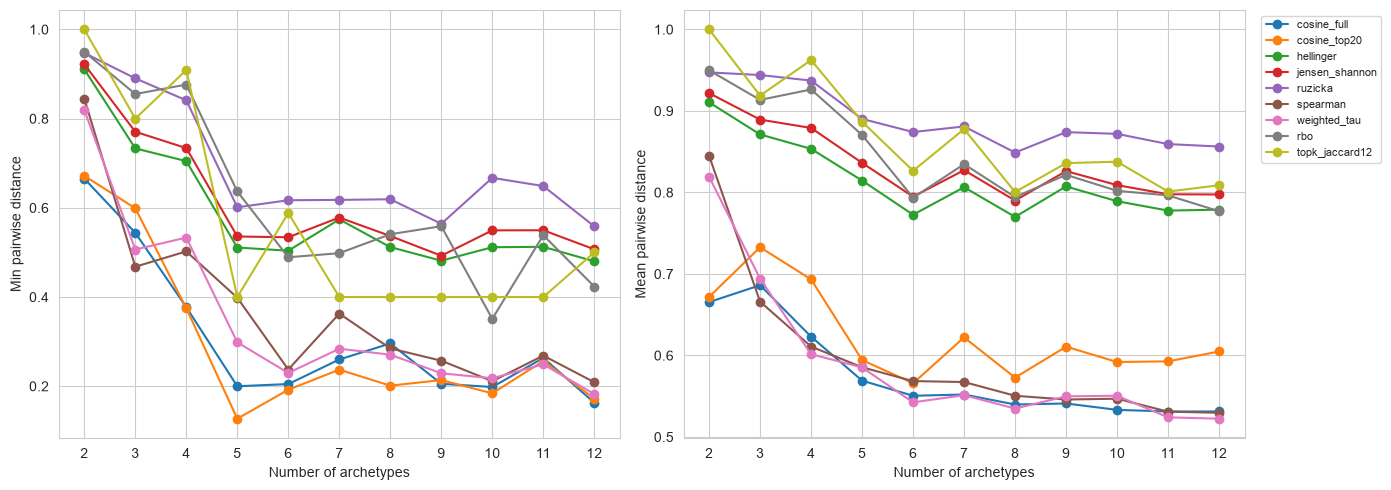

In [17]:
# --- Sweep p and watch the worst (most-overlapping) pair ----------------------
# Suggested p: the largest where the *min* pairwise distance stays high. Once the
# min drops, the extra archetype is mostly a near-duplicate of an existing one.

p_grid = list(range(2, 13))
sweep = {name: {'min': [], 'mean': []} for name in METRICS}

endm_by_p = {}

for p_try in tqdm.tqdm(p_grid):
    res_p = run_pipeline(Y, p=p_try, seed=SEED)
    endm_by_p[p_try] = res_p['endm']
    for name in METRICS:
        s = distinctness(res_p['endm'], name)
        sweep[name]['min'].append(s['min'])
        sweep[name]['mean'].append(s['mean'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for name in METRICS:
    axes[0].plot(p_grid, sweep[name]['min'], marker='o', label=name)
    axes[1].plot(p_grid, sweep[name]['mean'], marker='o', label=name)
axes[0].set_ylabel('Min pairwise distance')
axes[0].set_xlabel('Number of archetypes')
axes[1].set_ylabel('Mean pairwise distance')
axes[1].set_xlabel('Number of archetypes')
for ax in axes:
    # ax.set_xlabel('number of archetypes  p')
    # ax.set_ylabel('distinctness  (0–1)')
    ax.set_xticks(p_grid)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

min pairwise distance: distance between the most similar pair of archetypes within a run with p archetypes. across metrics, there is generally a continuous decrease in min pairwise distance until p=5, at which point increasing the p only causes distance to fluctuate around this value. another way to interpret this: at p=5, we start to see what we could count the most as duplicate archetypes. 

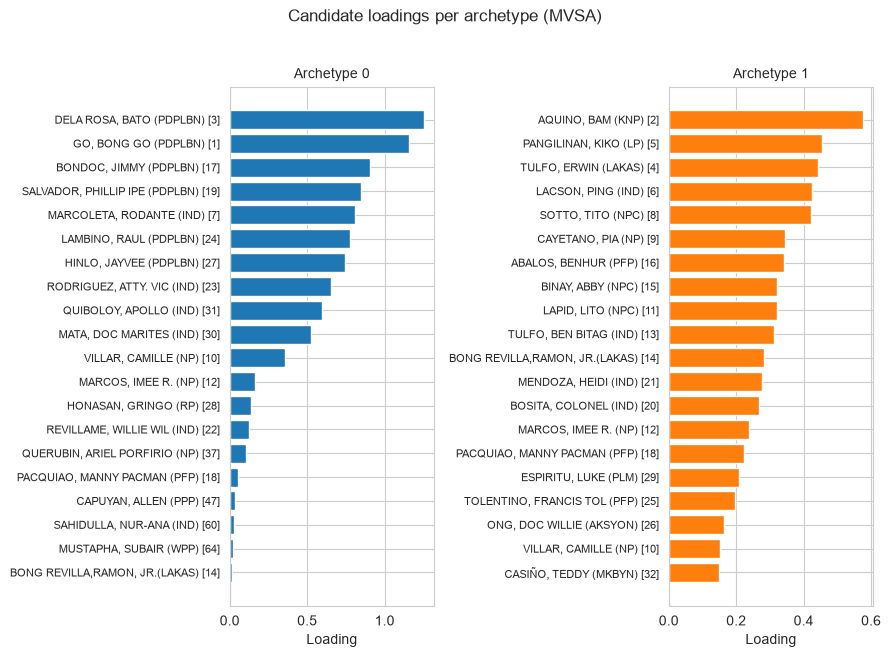

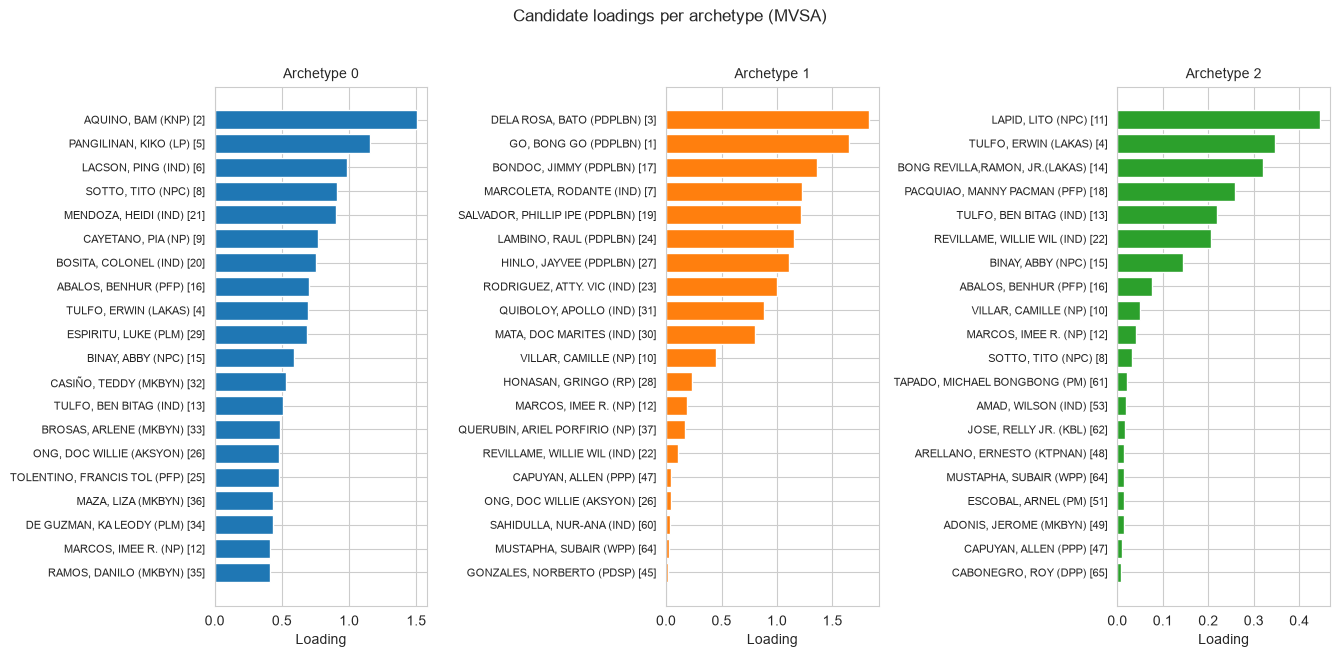

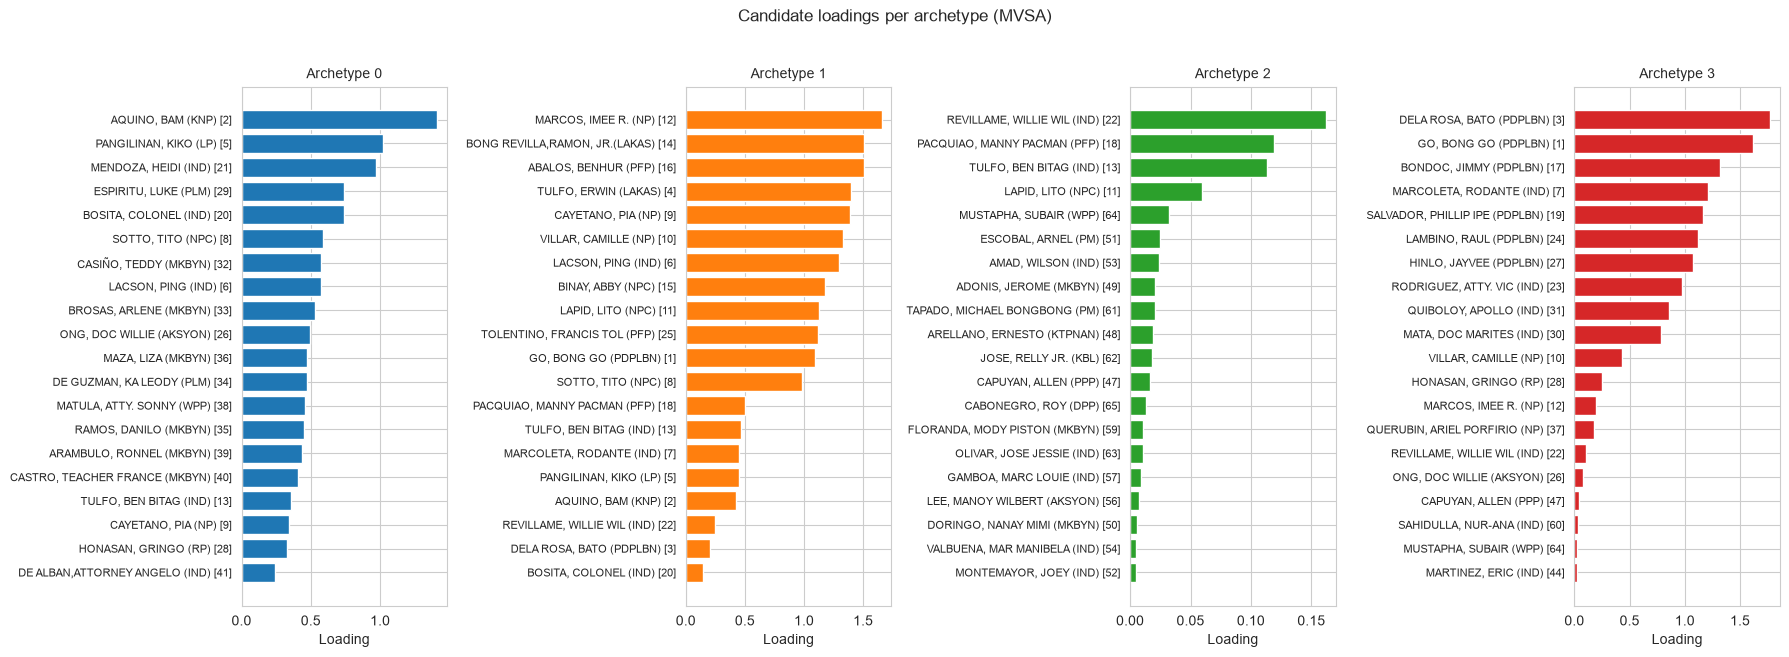

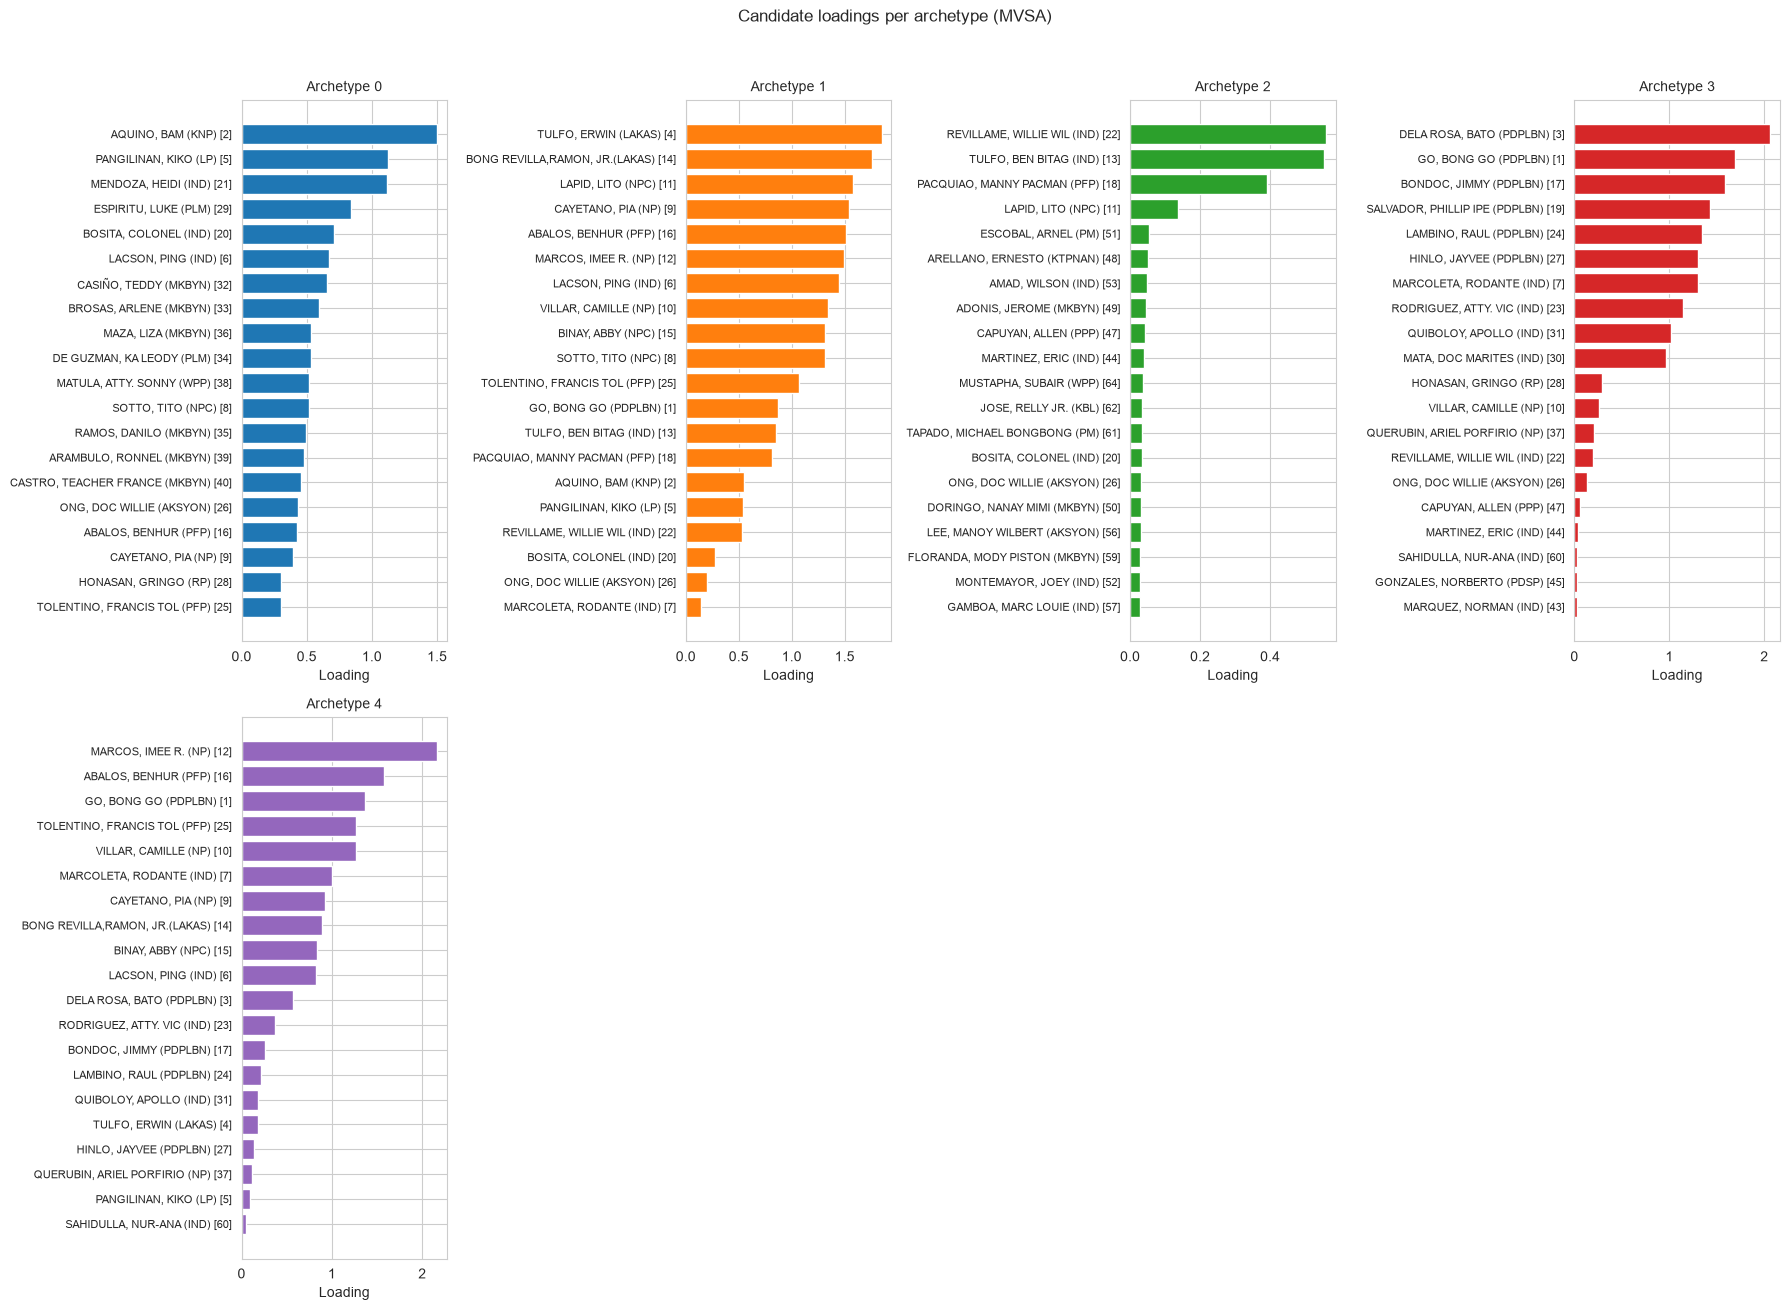

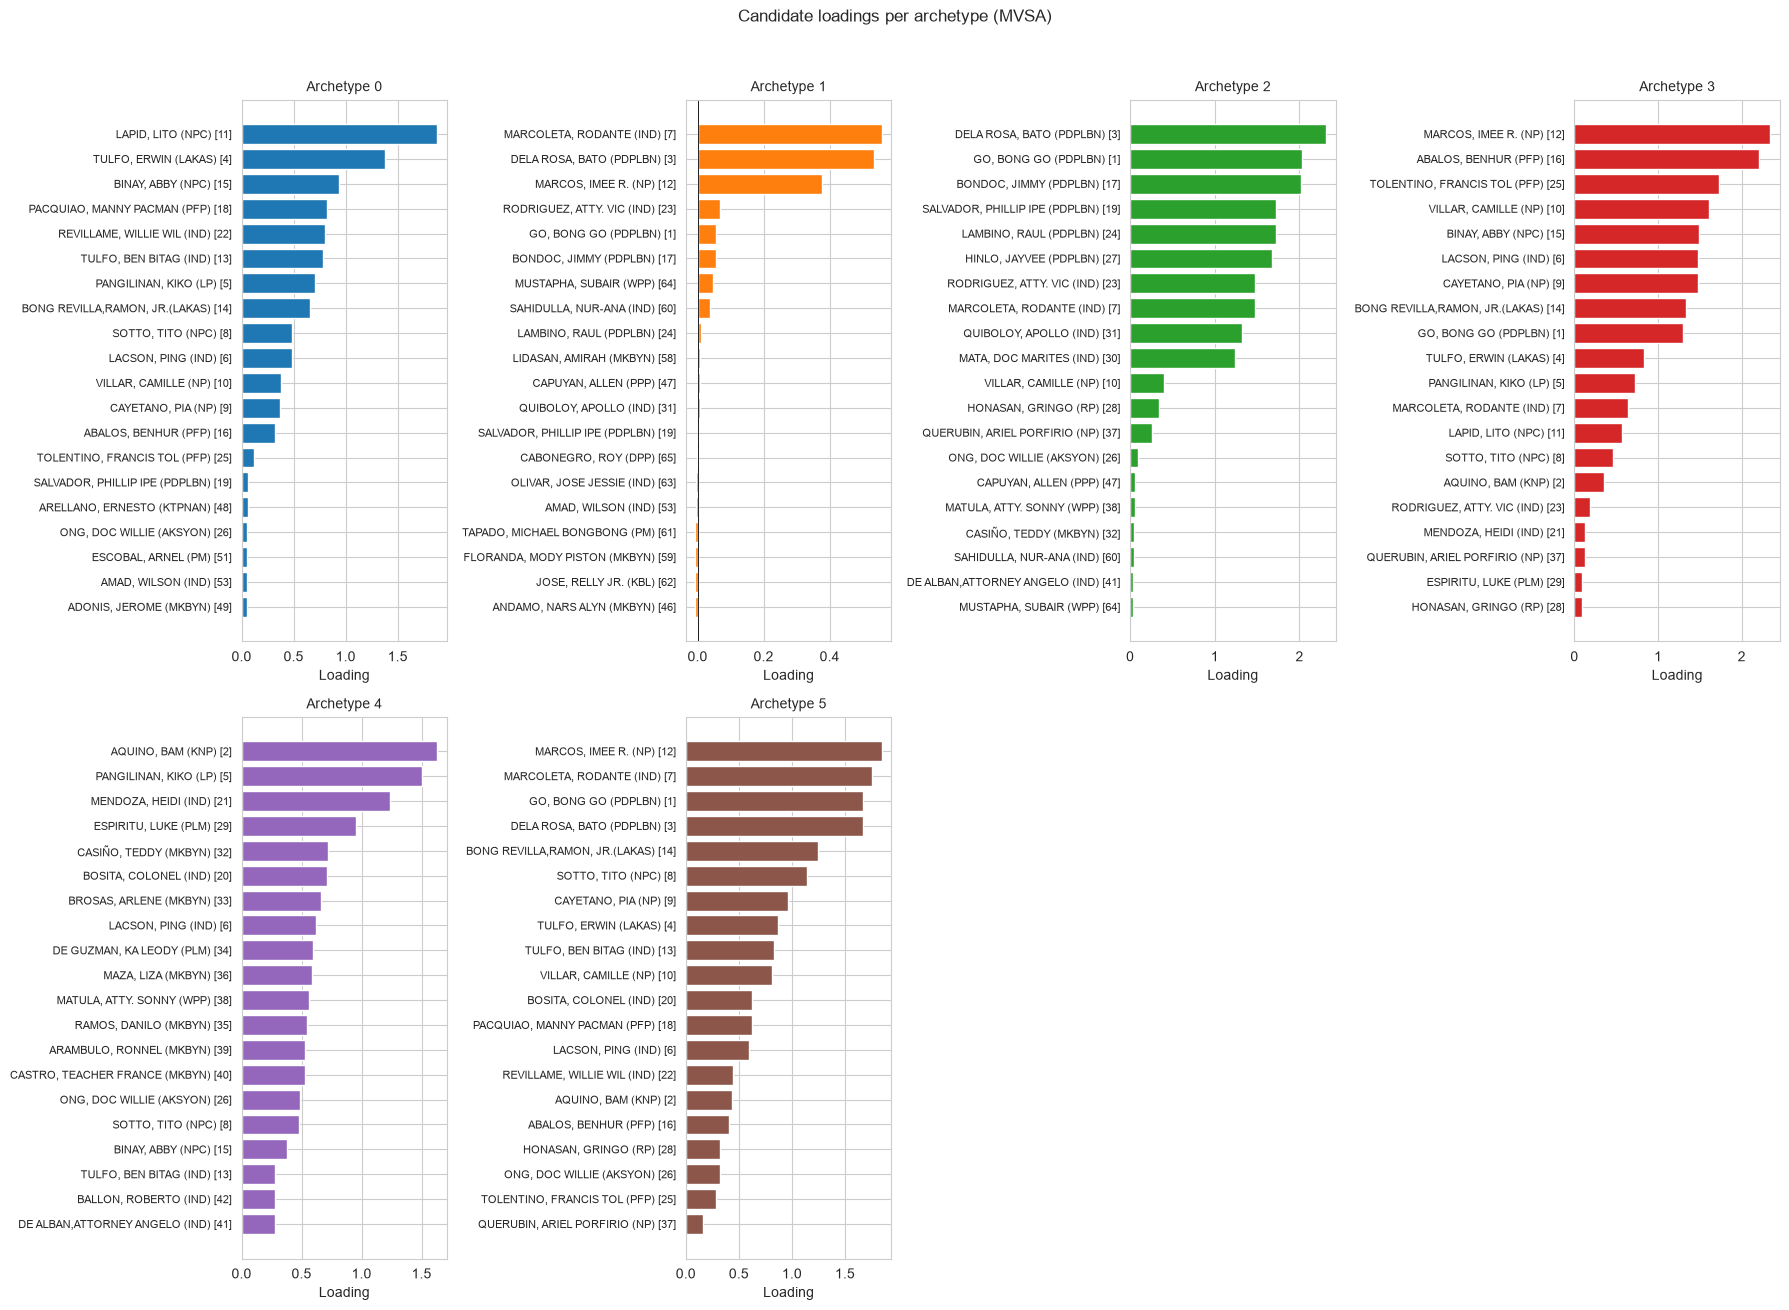

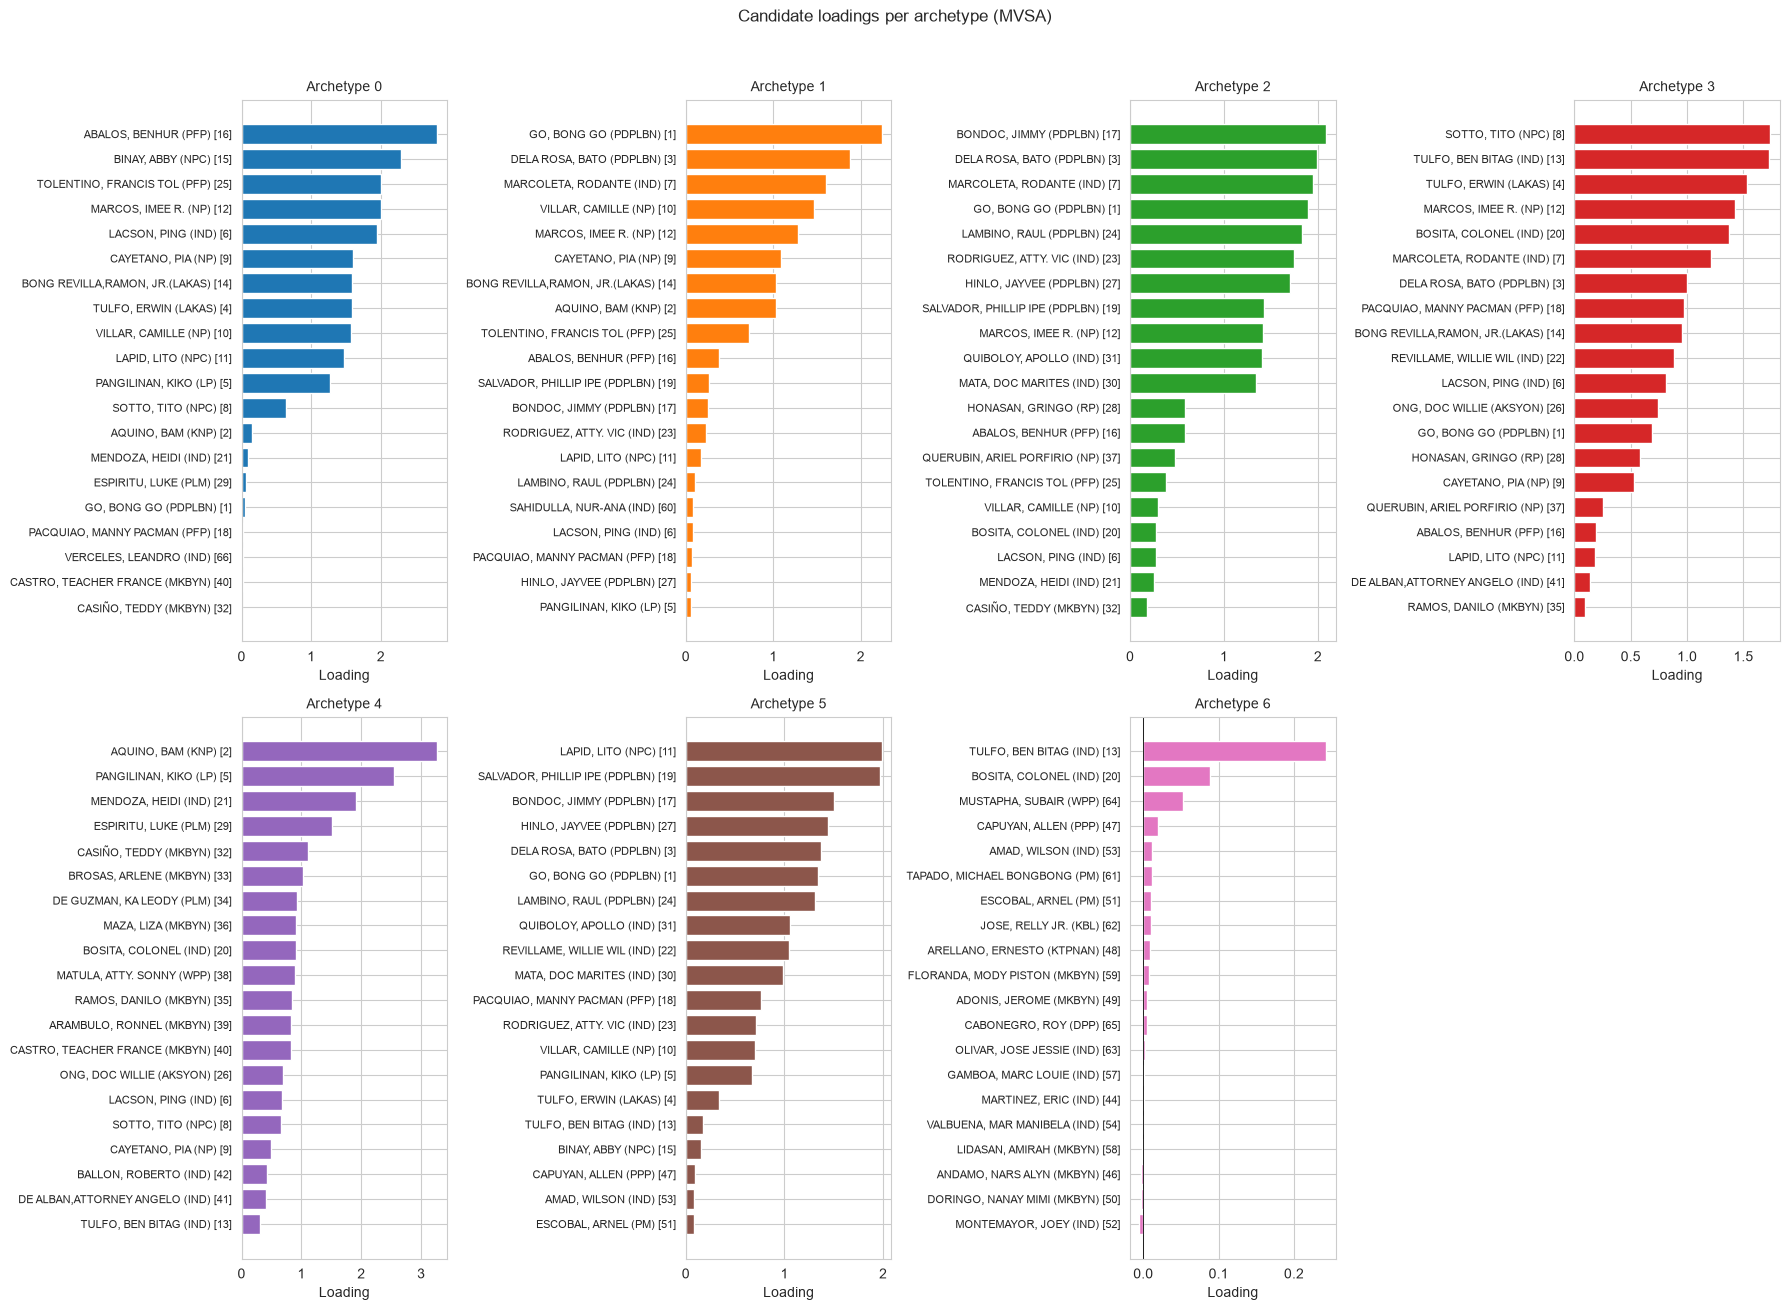

In [18]:
for i in range (2, 8):
    plot_archetypes_loadings_grid(endm_by_p[i], candidate_labels, top_n=20, suptitle='Candidate loadings per archetype (MVSA)')

In [ ]:
# TODO: replace the sankey diagram in the dashboard with this. specifically, 
# 1) calculate archetype similarity for each archetype between p's
# 2) based on similarity, connect the archetypes between p's 
# try: top 12 candidates per node, similarity for edge weights